In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

lr=0.01
epochs=1000
batch_size=64

In [ ]:
def real_plot(x):
  return x**2

In [ ]:
W1=torch.rand(1,32,requires_grad=True)
b1=torch.zeros(32,requires_grad=True)

W2=torch.rand(32,1,requires_grad=True)
b2=torch.zeros(1,requires_grad=True)

parameters=[W1,b1,W2,b2]

In [ ]:
def forward(x):
  z1=torch.matmul(x,W1)+b1

  a1=torch.sigmoid(z1)

  z2=torch.matmul(a1,W2)+b2

  return z2


In [ ]:
def train_poly():
  drift_hist=[]
  for epoch in range(epochs):
    x1=torch.empty(batch_size,1).uniform_(-5,5)
    x2=torch.empty(batch_size,1).uniform_(-5,5)

    y_diff_real=real_plot(x1)-real_plot(x2)

    x1_pred=forward(x1)
    x2_pred=forward(x2)
    y_diff_pred=x1_pred-x2_pred

    loss=torch.mean((y_diff_real-y_diff_pred)**2)
    loss.backward()

    with torch.no_grad():
      for p in parameters:
        p-=lr*p.grad

        p.grad.zero_()

    with torch.no_grad():
       f_zero = forward(torch.tensor([[0.0]])).item()
       drift_hist.append(f_zero)

    if epoch%200==0:
      print(f"Epoch {epoch}  Loss: {loss.item():.4f}  f(0) Prediction: {f_zero:.4f} (Should be 0)")

  return drift_hist




In [ ]:

def plot_results(drift_hist):

    x_vals_tensor = torch.linspace(-5, 5, 100).unsqueeze(1)

    with torch.no_grad():
        y_pred = forward(x_vals_tensor).numpy()

    x_vals = x_vals_tensor.numpy()
    y_true = real_plot(x_vals)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(x_vals, y_true, label="True Curve: $y = x^2$", color='blue', linewidth=3)
    ax1.plot(x_vals, y_pred, label="NN Prediction", color='red', linestyle='dashed', linewidth=3)
    ax1.axhline(0, color='black', linewidth=1)
    ax1.axvline(0, color='black', linewidth=1)
    ax1.set_title("True Function vs. NN Prediction")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(range(epochs), drift_hist, color='purple', linewidth=2)
    ax2.axhline(0, color='blue', linestyle='dashed', label="True Target for f(0)")
    ax2.set_title("Drift of f(0) over Training ")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Predicted Value of f(0)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Epoch 0  Loss: 162.9889  f(0) Prediction: 7.0546 (Should be 0)
Epoch 200  Loss: 14.5163  f(0) Prediction: -4.6703 (Should be 0)
Epoch 400  Loss: 3.0422  f(0) Prediction: -9.1813 (Should be 0)
Epoch 600  Loss: 1.0164  f(0) Prediction: -10.8037 (Should be 0)
Epoch 800  Loss: 0.4442  f(0) Prediction: -11.6949 (Should be 0)


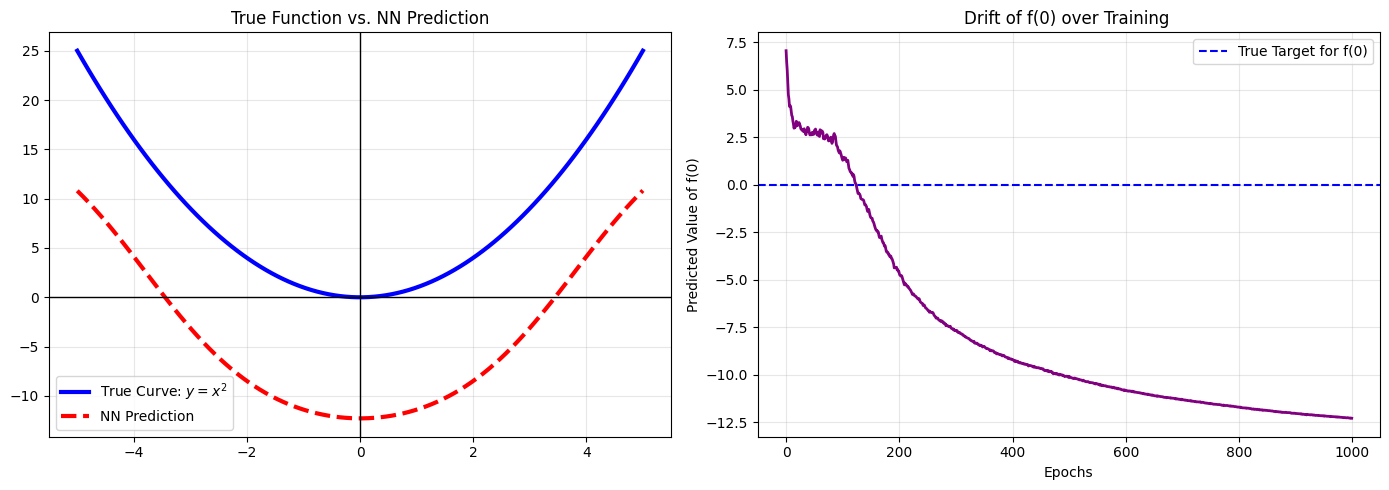

In [ ]:

if __name__ == "__main__":
    drift_hist = train_poly()
    plot_results(drift_hist)